# Getting started

`overviewpy` makes it easy to get an overview of a dataset by displaying relevant sample information.
This notebook walks through all currently implemented functions:

| Function | What it does |
|---|---|
| `overview_tab` | Tabular overview — one row per id with collapsed time ranges |
| `overview_na` | Bar chart of missing-value counts or percentages (column- or row-wise) |
| `overview_summary` | Per-column summary: non-null count, unique count, sample values |
| `overview_plot` | Connected dot-plot showing id × time coverage |
| `overview_overlap` | Bar chart or Venn diagram comparing ID coverage of two data frames |
| `overview_heat` | Heat map of observation counts (or percentages) per id-time combination |
| `overview_crossplot` | Scatter plot of two conditions with threshold lines dividing the plot into four quadrants |

All are available as methods on the `Overview` class, which is the recommended interface.

## Import libraries

We import the `Overview` class from `overviewpy`, along with `pandas` for data manipulation and `numpy` to produce missing values in our example data.

In [1]:
from overviewpy.overviewpy import Overview
import pandas as pd
import numpy as np

### Generate data

In the first step, we will generate some data that we will use in the next steps.

In [2]:
# Generate full data

data = {
        'id': ['RWA', 'RWA', 'RWA', 'GAB', 'GAB', 'FRA',\
            'FRA', 'BEL', 'BEL', 'ARG'],
        'year': [2022, 2023, 2021, 2023, 2020, 2019, 2015,\
            2014, 2013, 2002]
    }

df = pd.DataFrame(data)

df.head()

,id,year
0,RWA,2022
1,RWA,2023
2,RWA,2021
3,GAB,2023
4,GAB,2020


We also generate a second data frame that contains missing values (`np.nan`) in both the `id` and `year` columns. This dataset is used to demonstrate `overview_na` and the NA-handling behaviour of `overview_tab`.

In [3]:
# Generate data with missing values

data_na = {
        'id': ['RWA', 'RWA', 'RWA', np.nan, 'GAB', 'GAB',\
            'FRA', 'FRA', 'BEL', 'BEL', 'ARG', np.nan,  np.nan],
        'year': [2022, 2001, 2000, 2023, 2021, 2023, 2020,\
            2019,  np.nan, 2015, 2014, 2013, 2002]
    }

df_na = pd.DataFrame(data_na)

df_na.head()

,id,year
0,RWA,2022.0
1,RWA,2001.0
2,RWA,2000.0
3,NaN,2023.0
4,GAB,2021.0


### Get an overview of the time distribution in your data

Generate some general overview of the data set using the time and scope conditions with `overview_tab`. 
The resulting data frame collapses the time condition for each id by taking into account potential gaps in the time frame.

Consecutive years are compressed into a range (e.g. `2021-2023`); non-consecutive years appear as a comma-separated list (e.g. `2015, 2019`).

In [4]:
overview = Overview(df=df, id='id', time='year')
df_overview = overview.overview_tab()

print(df_overview)

    id  time_frame
9  ARG        2002
7  BEL   2013-2014
5  FRA  2015, 2019
3  GAB  2020, 2023
0  RWA   2021-2023


Missing values in `id` or `time` are automatically dropped and a `UserWarning` is raised for each affected variable. The code below captures those warnings explicitly so you can inspect them:

In [5]:
import warnings

data_with_na = {
    'id': ['RWA', 'RWA', np.nan, 'GAB'],
    'year': [2022, np.nan, 2021, 2020],
}
df_with_na = pd.DataFrame(data_with_na)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    overview_with_na = Overview(df=df_with_na, id='id', time='year')
    df_overview_na = overview_with_na.overview_tab()

for w in caught:
    print(w.message)

print(df_overview_na)

NameError: name 'warnings' is not defined

### Get an overview of missing data in your data frame

`overview_na` visualises missing values in your data. It returns a horizontal bar chart
showing the share of NAs per variable (column-wise, the default) or per observation
(row-wise). You can also augment the original data frame with the computed NA counts
and percentages.

| Parameter | Default | Description |
|-----------|---------|-------------|
| `yaxis` | `"Variables"` | y-axis label; auto-set to `"Observations"` when `row_wise=True` |
| `perc` | `True` | `True` = percentage of NAs, `False` = absolute counts |
| `row_wise` | `False` | `False` = per column, `True` = per row |
| `add` | `False` | when `True` (requires `row_wise=True`), returns the data frame extended with `na_count` and `percentage` instead of a plot |

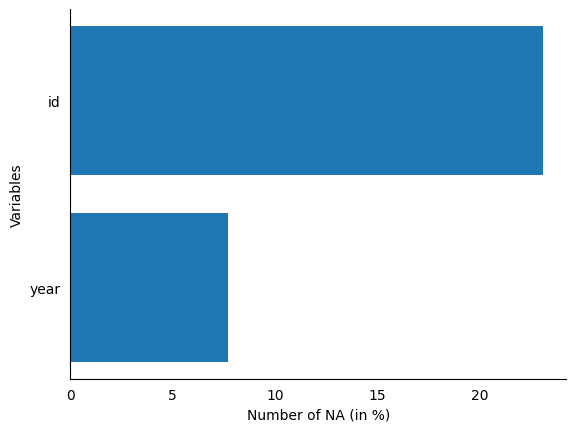

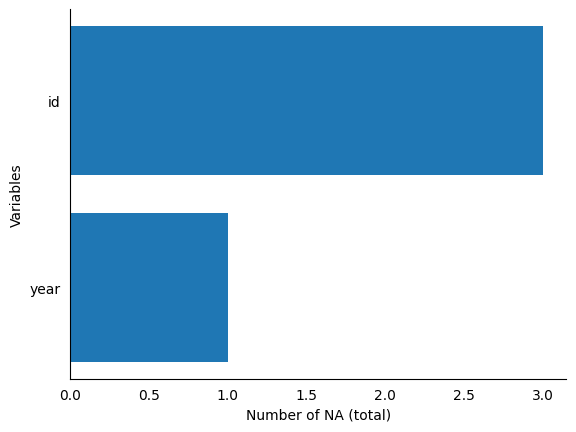

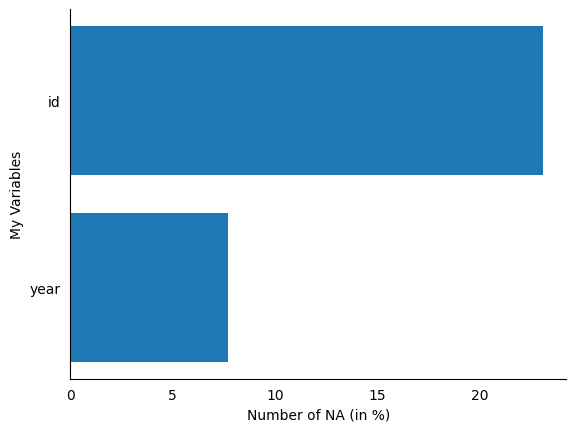

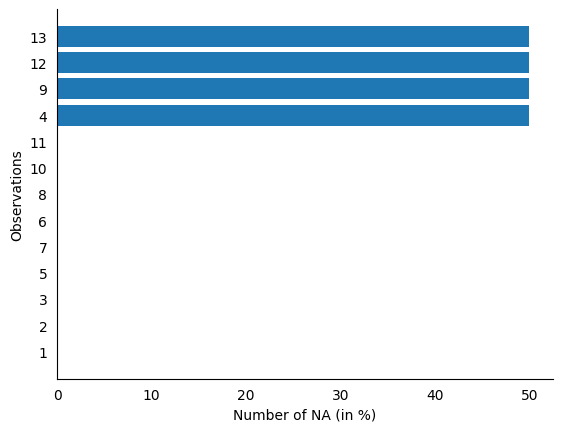

,id,year,na_count,percentage
0,RWA,2022.0,0,0.0
1,RWA,2001.0,0,0.0
2,RWA,2000.0,0,0.0
3,NaN,2023.0,1,50.0
4,GAB,2021.0,0,0.0
5,GAB,2023.0,0,0.0
6,FRA,2020.0,0,0.0
7,FRA,2019.0,0,0.0
8,BEL,NaN,1,50.0
9,BEL,2015.0,0,0.0


In [6]:
ov_na = Overview(df=df_na, id='id', time='year')

# Default: column-wise, percentage
ov_na.overview_na()

# Absolute counts instead of percentage
ov_na.overview_na(perc=False)

# Custom y-axis label
ov_na.overview_na(yaxis="My Variables")

# Row-wise: one bar per observation
ov_na.overview_na(row_wise=True)

# Row-wise and augment the data frame with na_count and percentage columns
ov_na.overview_na(row_wise=True, add=True)

### Get a column-level summary of your data frame

`overview_summary` returns a data frame with one row per column, showing:

* `non_null_count` — number of non-missing values
* `unique_count` — number of distinct non-missing values
* `sample_values` — up to 5 example values

It works on any data frame regardless of whether `id` and `time` are set.

In [7]:
ov_na.overview_summary()

,non_null_count,unique_count,sample_values
column,,,
id,10,5,"[RWA, GAB, FRA, BEL, ARG]"
year,12,11,"[2022.0, 2001.0, 2000.0, 2023.0, 2021.0]"


### Visualize observation coverage across id and time

`overview_plot` creates a connected dot-plot showing which id–time combinations are
present in the data:

* each id is a row on the y-axis
* time is on the x-axis
* **consecutive** years are joined by a line; **gaps** produce separate point clusters

This makes it easy to spot coverage gaps at a glance.

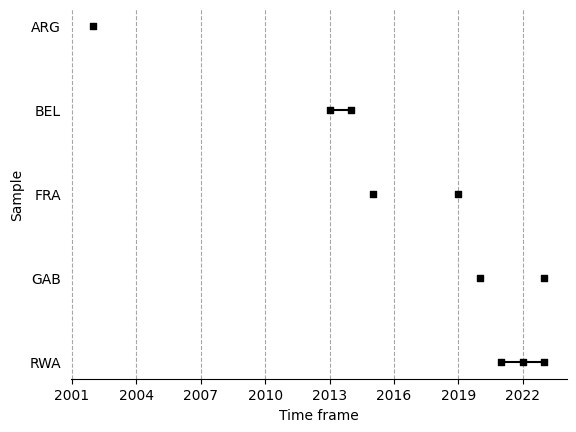

<Axes: xlabel='Time frame', ylabel='Sample'>

In [8]:
# Basic coverage plot
overview.overview_plot()

#### Color-coding by a third variable

Pass any column name to `color` to color-code each point by that variable.
A legend is added automatically at the bottom of the plot.

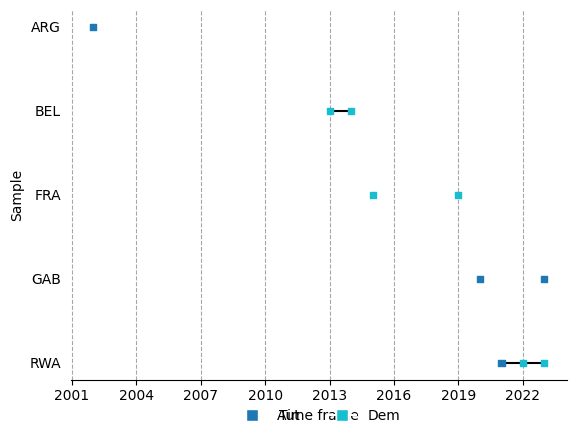

<Axes: xlabel='Time frame', ylabel='Sample'>

In [9]:
data_color = {
    'id':     ['RWA', 'RWA', 'RWA', 'GAB', 'GAB', 'FRA', 'FRA', 'BEL', 'BEL', 'ARG'],
    'year':   [2022,  2023,  2021,  2023,  2020,  2019,  2015,  2014,  2013,  2002],
    'regime': ['Dem', 'Dem', 'Aut', 'Aut', 'Aut', 'Dem', 'Dem', 'Dem', 'Dem', 'Aut'],
}

df_color = pd.DataFrame(data_color)
ov_color = Overview(df=df_color, id='id', time='year')

ov_color.overview_plot(color='regime')

#### Additional parameters

`overview_plot` exposes several parameters for fine-tuning the output:

| Parameter | Default | Description |
|---|---|---|
| `xaxis` | `"Time frame"` | x-axis label |
| `yaxis` | `"Sample"` | y-axis label |
| `asc` | `True` | Sort ids top-to-bottom in ascending order |
| `color` | `None` | Column name to color-code points by |
| `dot_size` | `2` | Size of the plotted squares |
| `show_plot` | `True` | Display the plot inline; set to `False` to return the axes object only |

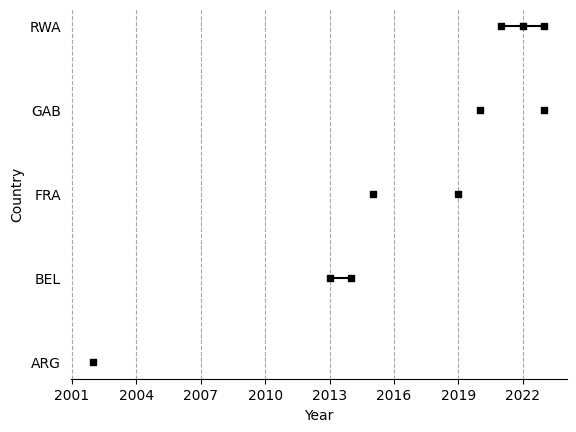

<Axes: xlabel='Year', ylabel='Country'>

In [10]:
# Custom axis labels and descending id order
overview.overview_plot(
    xaxis='Year',
    yaxis='Country',
    asc=False,
)

### Compare the overlap of two data frames

`overview_overlap` compares the ID coverage of two data frames. Call it on an `Overview` instance and pass the second data frame as `dat2`.

- `plot_type="bar"` (default) — grouped bar chart showing observation counts per identifier.
- `plot_type="venn"` — Venn diagram showing the number of IDs unique to each data set and shared between both.

In [ ]:
# Generate a second data frame that partially overlaps with df
data2 = {
    'id':   ['RWA', 'GAB', 'GAB', 'ARG', 'ARG'],
    'year': [2022, 2023, 2020, 2019, 2018]
}
df2 = pd.DataFrame(data2)

# Bar chart (default)
overview.overview_overlap(dat2=df2, dat2_id='id', dat1_name='Survey 1', dat2_name='Survey 2')

In [ ]:
# Venn diagram
overview.overview_overlap(dat2=df2, dat2_id='id', dat1_name='Survey 1', dat2_name='Survey 2', plot_type='venn')

### Visualize sample coverage as a heat map

`overview_heat` plots a heat map that shows how many observations exist for each id-time combination. Set `perc=True` together with `exp_total` to display coverage as a percentage of the expected maximum.

In [ ]:
overview.overview_heat()

In [ ]:
overview.overview_heat(perc=True, exp_total=3)

### Visualize two conditions against their thresholds

`overview_crossplot` plots a scatter of two numeric conditions, drawing vertical and horizontal lines
at user-defined thresholds to divide observations into four quadrants.
Data are aggregated to (id, time) means before plotting, so duplicate rows are handled automatically.

In [ ]:
# Generate data with two numeric conditions
data_cross = {
    'id':         ['RWA', 'RWA', 'GAB', 'GAB', 'FRA', 'FRA', 'BEL', 'ARG'],
    'year':       [2020,  2021,  2020,  2021,  2020,  2021,  2020,  2020],
    'gdp':        [8000,  9000,  22000, 24000, 40000, 42000, 35000, 12000],
    'population': [13e6,  13.5e6, 2.2e6, 2.3e6, 67e6, 68e6, 11e6,  45e6],
}
df_cross = pd.DataFrame(data_cross)

ovw_cross = Overview(df=df_cross, id='id', time='year')

# Basic crossplot: threshold lines divide the scatter into four quadrants
ovw_cross.overview_crossplot(
    cond1='gdp',
    cond2='population',
    threshold1=25000,
    threshold2=27e6,
)

In [ ]:
# With quadrant coloring and point labels
ovw_cross.overview_crossplot(
    cond1='gdp',
    cond2='population',
    threshold1=25000,
    threshold2=27e6,
    color=True,
    label=True,
    xaxis='GDP per capita',
    yaxis='Population',
)